In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Задача исследовать файл bike_share/usage_frequency.csv

- читаю файл bike_share/usage_frequency.csv

In [2]:
usage_frequency = pd.read_csv('../../bike_share/usage_frequency.csv')
usage_frequency

,date,station_name,pickup_counts,dropoff_counts
0,2020-05-01,10th & E St NW,11,7.0
1,2020-05-01,10th & Florida Ave NW,8,8.0
2,2020-05-01,10th & G St NW,3,2.0
3,2020-05-01,10th & K St NW,12,15.0
4,2020-05-01,10th & Monroe St NE,5,6.0
...,...,...,...,...
873313,2024-08-31,Wisconsin Ave & Upton St NW,28,26.0
873314,2024-08-31,Woodglen Dr & Executive Blvd,4,1.0
873315,2024-08-31,Woodley Park Metro / Calvert St & Connecticut ...,34,34.0
873316,2024-08-31,Woodmont Ave & Strathmore St,10,7.0


- сразу поменяю тип данных для столбца date на datetime64[ns]

In [ ]:
usage_frequency['date'] = usage_frequency['date'].astype('datetime64[ns]')

### Общая информация о данных 

- смотрю информацию

In [27]:
usage_frequency.info()

<class 'pandas.DataFrame'>
RangeIndex: 873318 entries, 0 to 873317
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date            873318 non-null  datetime64[ns]
 1   station_name    873318 non-null  str           
 2   pickup_counts   873318 non-null  int64         
 3   dropoff_counts  873318 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), str(1)
memory usage: 26.7 MB


In [46]:
usage_frequency.describe()

,date,pickup_counts,dropoff_counts,change
count,873318,873318.000000,873318.000000,873318.000000
mean,2022-08-18 13:39:28.135318784,16.759666,16.555958,0.203708
min,2020-05-01 00:00:00,1.000000,0.000000,-194.000000
25%,2021-07-26 00:00:00,3.000000,2.000000,-1.000000
50%,2022-09-10 00:00:00,8.000000,7.000000,0.000000
75%,2023-09-19 00:00:00,23.000000,23.000000,2.000000
max,2024-08-31 00:00:00,444.000000,460.000000,96.000000
std,NaN,21.986585,22.237560,4.922714


### Отсутствующие значения

- смотрю отсутствующие занчения

In [28]:
usage_frequency.isna().sum()

date              0
station_name      0
pickup_counts     0
dropoff_counts    0
dtype: int64

- смотрю сколько уникальных значаний в столбце station_name (совпадает с количеством станций в файле 'station_list')

### Дубликаты

In [4]:
len(usage_frequency['station_name'].unique())

908

- проверяю что даты идут с частотой в один день (использую pd.infer_freq())

In [20]:
pd.infer_freq(pd.DataFrame(usage_frequency['date'].unique())[0].astype('datetime64[ns]'))

'D'

### Описательная статистика

In [21]:
usage_frequency['pickup_counts'].min(), usage_frequency['pickup_counts'].max()

(np.int64(1), np.int64(444))

In [22]:
usage_frequency['dropoff_counts'].min(), usage_frequency['dropoff_counts'].max()

(np.float64(0.0), np.float64(460.0))

- строю график

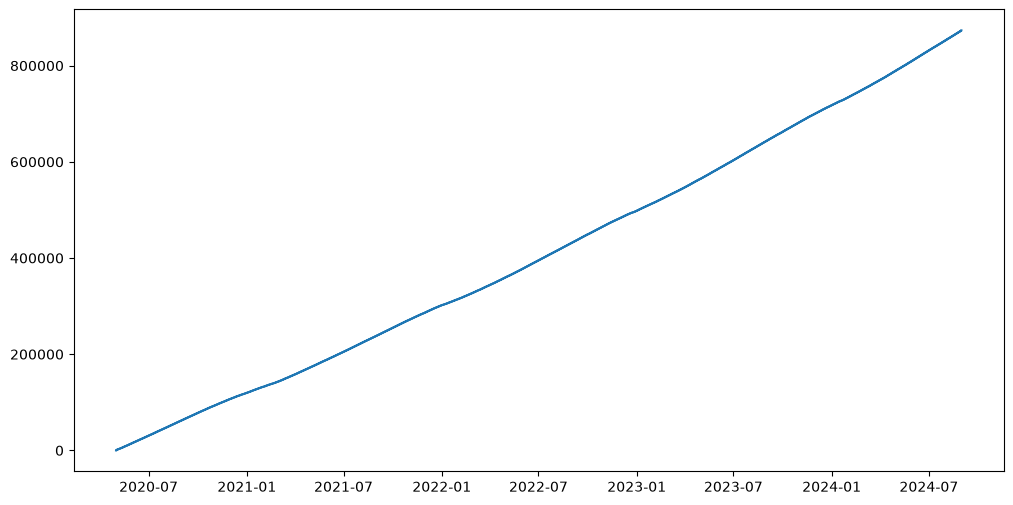

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    usage_frequency['date'],
    usage_frequency.index
)


plt.show()

- делаю группировку по стобцу date и считаю station_name и строю график

<Axes: xlabel='date'>

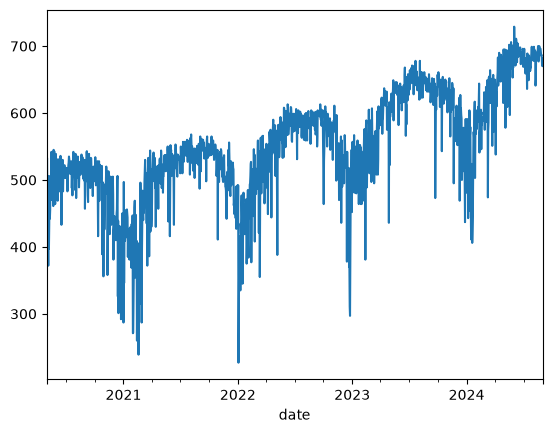

In [33]:
usage_frequency.groupby('date')['station_name'].count().plot()

- на первом графике выидно что линия не прямая (что предположительно это сезон)
- на втором более отчетлива видно что это сезонность

### Добавление нового столбца (это разница между взятыми и оставленными велосипедами)

- добавляю новый столбец change (это разница между звятыми велосипедами и оставленными)

In [34]:
usage_frequency.columns

Index(['date', 'station_name', 'pickup_counts', 'dropoff_counts'], dtype='str')

In [35]:
usage_frequency['change'] = usage_frequency['pickup_counts'] - usage_frequency['dropoff_counts']

In [36]:
usage_frequency

,date,station_name,pickup_counts,dropoff_counts,change
0,2020-05-01,10th & E St NW,11,7.0,4.0
1,2020-05-01,10th & Florida Ave NW,8,8.0,0.0
2,2020-05-01,10th & G St NW,3,2.0,1.0
3,2020-05-01,10th & K St NW,12,15.0,-3.0
4,2020-05-01,10th & Monroe St NE,5,6.0,-1.0
...,...,...,...,...,...
873313,2024-08-31,Wisconsin Ave & Upton St NW,28,26.0,2.0
873314,2024-08-31,Woodglen Dr & Executive Blvd,4,1.0,3.0
873315,2024-08-31,Woodley Park Metro / Calvert St & Connecticut ...,34,34.0,0.0
873316,2024-08-31,Woodmont Ave & Strathmore St,10,7.0,3.0


In [39]:
usage_frequency['change'].mean()

np.float64(0.20370815670809486)

In [40]:
usage_frequency['change'].median()

np.float64(0.0)

<Axes: >

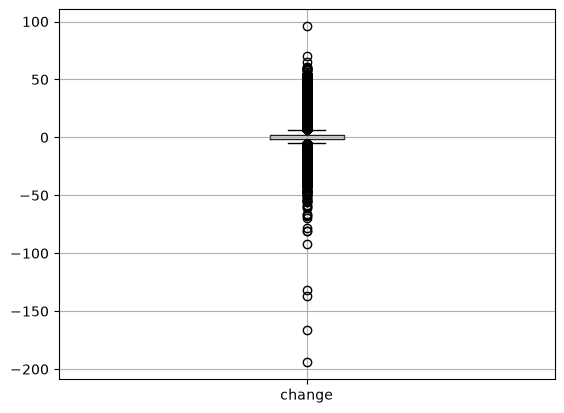

In [ ]:
usage_frequency.boxplot(column='change')

- выбросы имеют не симметричное распределение (имеет левостороннюю асимметрию)
- медиана состовляет 0 (посчитано выше)
- основная масса разницы лежит от -3 до 7


In [43]:
usage_frequency.columns

Index(['date', 'station_name', 'pickup_counts', 'dropoff_counts', 'change'], dtype='str')

- вывожу график (разница между pickup_counts и dropoff_counts за период с 2020 по 2024 год)

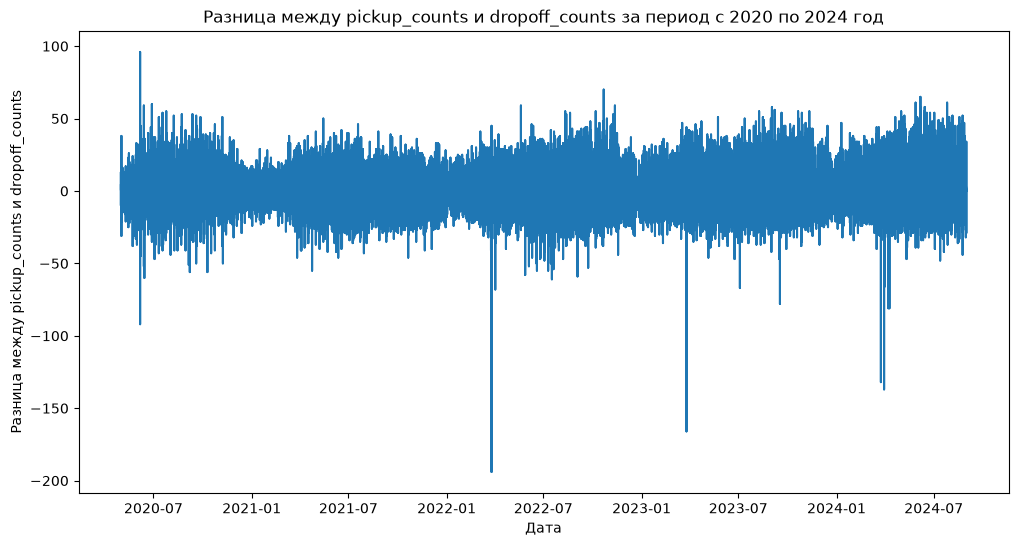

In [45]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    usage_frequency['date'],
    usage_frequency['change']
)

plt.xlabel('Дата')
plt.ylabel('Разница между pickup_counts и dropoff_counts')
plt.title('Разница между pickup_counts и dropoff_counts за период с 2020 по 2024 год')

plt.show()

## Вывод
- нет отсутствующих значений
- есть большие выбросы в столбце change (это разница между взятыми и оставленными велосипедами),
- вероятно это связанно с перегружанностью или не достатком велосипедов на станции
    - макс. значение pickup_counts 444
    - макс. значение dropoff_counts 460